In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pycaret.regression import *

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, PowerTransformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor

In [3]:
player_data = pd.read_csv('./rolled_data_24_25.csv')

gk_data = player_data[player_data['position'] == 'Goalkeeper']
def_data = player_data[player_data['position'] == 'Defender']
mid_data = player_data[player_data['position'] == 'Midfielder']
fwd_data = player_data[player_data['position'] == 'Forward']

# GK


In [4]:
feats_gk = [
    'value', 'win_prob', 'xP', 'points_1_ewm', 'xP_3_ewm', 'minutes_5_ewm', 'yellow_cards_3_ewm', 'clean_sheets_per_90_3_ewm', 'saves_per_90_3_ewm',
    'expected_goals_conceded_per_90_3_ewm',  'goals_prevented_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm', 'opponent_xG_3_ewm', 'shots_faced_3_ewm'
    ]

working_gk_df  = gk_data[feats_gk]

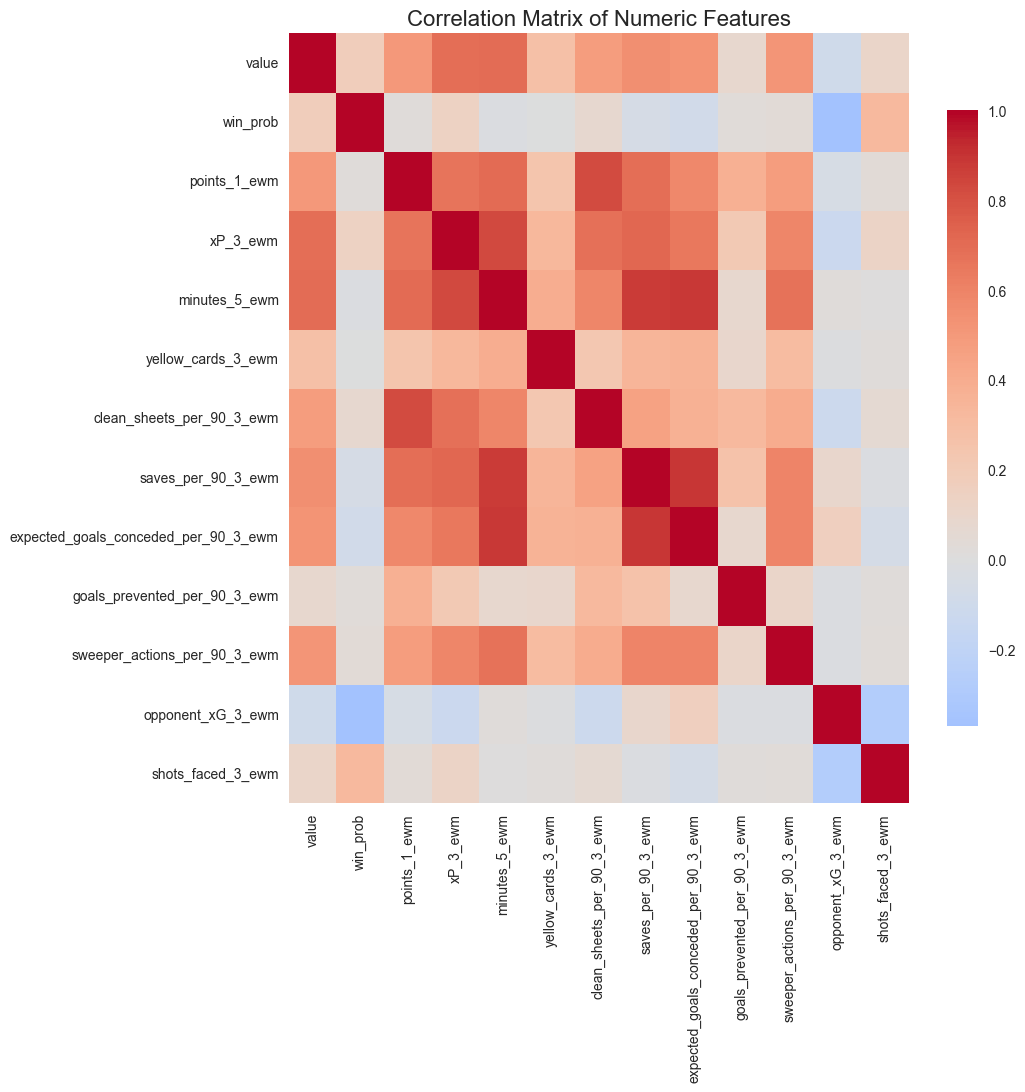

In [5]:
# Select only numeric features (exclude the target 'price')
numeric_df = working_gk_df.select_dtypes(include=['float64', 'int64']).drop(columns=["xP"], errors="ignore")

# Compute correlation matrix
corr_matrix = numeric_df.corr()


# Display full matrix as heatmap
plt.figure(figsize=(10,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,   # set to True if you want numbers on cells
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()

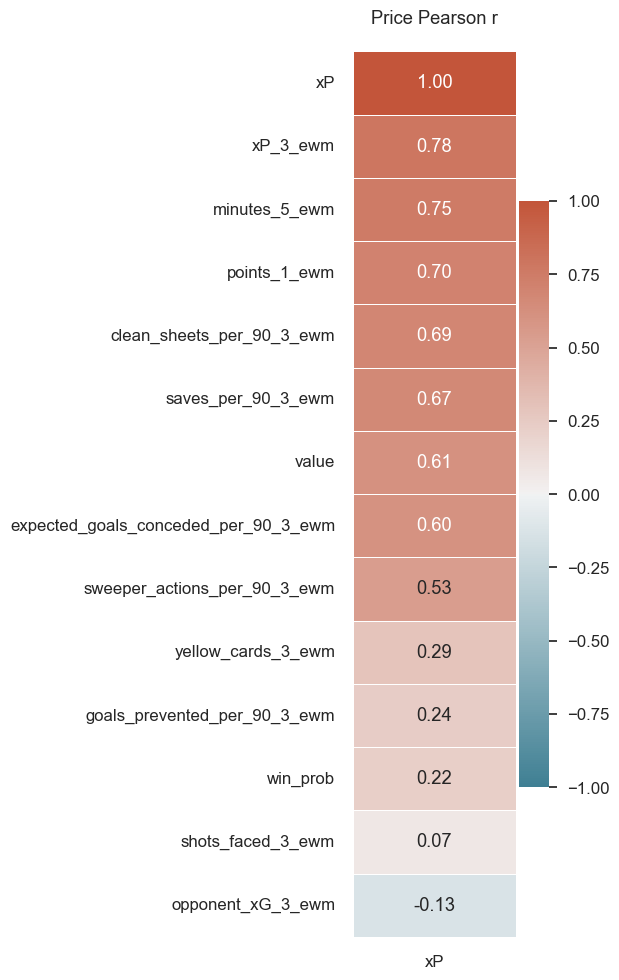

In [6]:

# Compute correlations with price
num_cols = working_gk_df.select_dtypes("number").columns
corr_vec  = working_gk_df[feats_gk].corr(method="pearson")["xP"].sort_values(ascending=False)
sns.set_theme(style="white")
sns.set(font_scale=1.1)
plt.figure(figsize=(6,10))
ax = sns.heatmap(
        corr_vec.to_frame(),
        annot=True, fmt=".2f",
        vmin=-1, vmax=1,
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        center=0,
        linewidths=.5, linecolor="white",
        cbar_kws={"shrink":0.8, "pad":0.02}
     )
ax.set_title("Price Pearson r", pad=20)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [7]:
final_gk_data = working_gk_df[feats_gk]
final_gk_data[['round', 'element', 'was_home']] = gk_data[['round', 'element','was_home']]
# Convert boolean to integer (True -> 1, False -> 0)
final_gk_data["was_home"] = final_gk_data["was_home"].astype(int)
final_gk_data = final_gk_data.fillna(0)
final_gk_data

,value,win_prob,xP,points_1_ewm,xP_3_ewm,minutes_5_ewm,yellow_cards_3_ewm,clean_sheets_per_90_3_ewm,saves_per_90_3_ewm,expected_goals_conceded_per_90_3_ewm,goals_prevented_per_90_3_ewm,sweeper_actions_per_90_3_ewm,opponent_xG_3_ewm,shots_faced_3_ewm,round,element,was_home
148,40.0,0.801,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,1,5,1
149,40.0,0.536,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.470000,6.0000,2,5,0
150,40.0,0.715,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.755000,6.0000,3,5,1
151,40.0,0.413,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.257500,6.5000,4,5,0
152,40.0,0.211,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.018750,5.2500,5,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26820,40.0,0.207,0.0,0.0,-0.081250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.748125,2.0000,34,788,0
26821,40.0,0.199,0.0,0.0,-0.040625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.189062,4.5000,35,788,0
26822,40.0,0.499,0.0,0.0,-0.020313,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.024531,7.7500,36,788,1
26823,40.0,0.152,0.0,0.0,-0.010156,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.292266,6.3750,37,788,0


## Baseline Model


In [8]:
from pycaret.regression import *

import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# from sklearn.preprocessing import test

from pycaret.regression import *

In [9]:
final_gk_data
gk_df = final_gk_data[(final_gk_data['minutes_5_ewm'] > 30)]
gk_df

,value,win_prob,xP,points_1_ewm,xP_3_ewm,minutes_5_ewm,yellow_cards_3_ewm,clean_sheets_per_90_3_ewm,saves_per_90_3_ewm,expected_goals_conceded_per_90_3_ewm,goals_prevented_per_90_3_ewm,sweeper_actions_per_90_3_ewm,opponent_xG_3_ewm,shots_faced_3_ewm,round,element,was_home
485,44.0,0.426,2.0,3.0,0.925000,50.000000,0.000000,0.0,4.500000,2.030000,0.560000,0.500000,2.855000,2.875000,5,14,1
486,44.0,0.190,2.2,3.0,1.462500,63.333333,0.000000,0.0,4.750000,1.860000,1.305000,1.250000,2.272500,2.937500,6,14,0
487,44.0,0.056,1.0,2.0,1.831250,72.222222,0.000000,0.0,3.875000,1.620000,-0.037500,1.125000,1.736250,3.468750,7,14,0
488,44.0,0.413,1.2,2.0,1.415625,78.148148,0.000000,0.0,3.437500,2.225000,-0.188750,0.562500,2.063125,2.734375,8,14,1
489,44.0,0.056,0.7,1.0,1.307812,82.098765,0.000000,0.0,2.218750,2.717500,-0.329375,0.281250,2.636563,4.867188,9,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26503,45.0,0.073,0.0,1.0,0.490625,87.658893,0.375000,0.0,4.472656,2.413594,-0.145684,1.101562,2.473906,2.294922,34,764,0
26504,45.0,0.143,0.7,1.0,0.245312,88.439262,0.187500,0.0,3.236328,2.631797,-0.572842,0.550781,2.401953,2.147461,35,764,0
26505,45.0,0.189,1.0,1.0,0.472656,88.959508,0.093750,0.0,2.118164,1.590898,-0.546421,1.775391,2.070977,2.073730,36,764,1
26506,45.0,0.326,1.5,3.0,0.736328,89.306339,0.046875,0.0,3.059082,1.500449,-0.173210,0.887695,1.640488,3.036865,37,764,0


In [11]:
gk_tar = gk_df['xP']
gk_feats = gk_df.drop(columns=['xP'])
gk_tar

485      2.0
486      2.2
487      1.0
488      1.2
489      0.7
        ... 
26503    0.0
26504    0.7
26505    1.0
26506    1.5
26507    0.7
Name: xP, Length: 793, dtype: float64

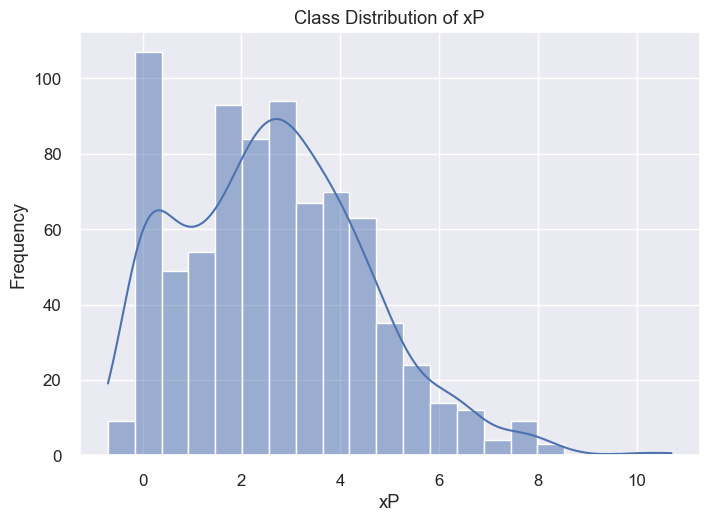

In [12]:
sns.histplot(gk_tar, kde=True)
plt.title('Class Distribution of xP')
plt.xlabel('xP')
plt.ylabel('Frequency')
plt.show()

<Axes: ylabel='Count'>

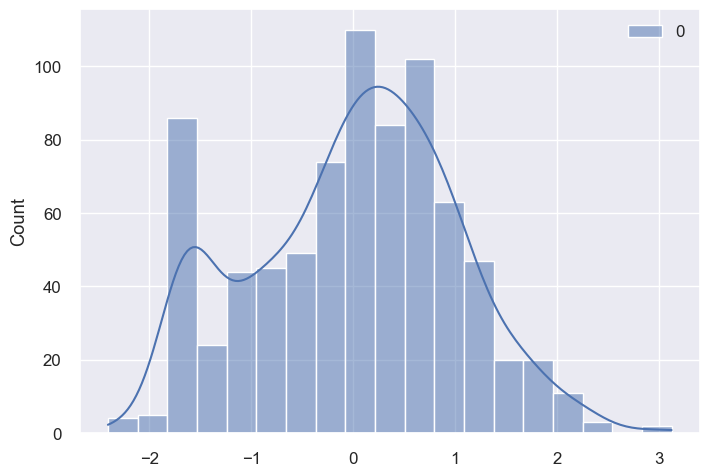

In [13]:
pt_xp = PowerTransformer(method='yeo-johnson', standardize=True)
v = pt_xp.fit_transform(gk_tar.values.reshape(-1,1))

sns.histplot(v, kde=True)

## Pycaret


In [14]:

models = {}
for i in [6, 10, 20, 30]:
    train_data = final_gk_data[(final_gk_data['round'] < i) & (final_gk_data['minutes_5_ewm'] > 15)][feats_gk]
    test_data = final_gk_data[final_gk_data['round'] == i][feats_gk]

    y_train = train_data['xP']
    X_train = train_data.drop(columns='xP')

    y_test = test_data['xP']
    X_test = test_data.drop(columns='xP')


    print(f'Modelling for gameweek {i}')
    model = setup(train_data, target = 'xP', train_size=0.8, session_id=42)

    model_best = model.compare_models(sort='MAE', n_select=1)

    models[i] = model_best


Modelling for gameweek 6


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(92, 14)"
4,Transformed data shape,"(92, 14)"
5,Transformed train set shape,"(73, 14)"
6,Transformed test set shape,"(19, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,1.0171,1.8576,1.3111,0.2362,0.3437,0.5409,0.0100
huber,Huber Regressor,1.0398,1.9071,1.3394,0.2757,0.3612,0.5026,0.0160
lr,Linear Regression,1.0577,1.9199,1.3394,0.2149,0.3525,0.5622,0.3640
br,Bayesian Ridge,1.0731,1.9183,1.3238,0.1939,0.3510,0.5995,0.0110
et,Extra Trees Regressor,1.1157,2.0109,1.3939,0.1812,0.3691,0.6086,0.0360
ada,AdaBoost Regressor,1.1335,1.9308,1.3731,0.2310,0.3892,0.7290,0.0300
rf,Random Forest Regressor,1.1596,2.0382,1.4078,0.1897,0.3858,0.6436,0.0530
en,Elastic Net,1.1689,2.1579,1.4181,0.1261,0.3771,0.7439,0.0090
gbr,Gradient Boosting Regressor,1.2107,2.5184,1.5535,-0.0140,0.3963,0.5819,0.0210
lasso,Lasso Regression,1.2353,2.3183,1.4754,0.1045,0.3928,0.8202,0.2410


Modelling for gameweek 10


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(186, 14)"
4,Transformed data shape,"(186, 14)"
5,Transformed train set shape,"(148, 14)"
6,Transformed test set shape,"(38, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


...

,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(435, 14)"
4,Transformed data shape,"(435, 14)"
5,Transformed train set shape,"(348, 14)"
6,Transformed test set shape,"(87, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.7788,1.0698,1.0192,0.6725,0.3226,0.4992,0.0070
lr,Linear Regression,0.7803,1.0702,1.0195,0.6722,0.3234,0.4998,0.0060
br,Bayesian Ridge,0.7815,1.0825,1.0252,0.6687,0.3237,0.5010,0.0080
huber,Huber Regressor,0.7867,1.0946,1.0302,0.6639,0.3264,0.5113,0.0120
lar,Least Angle Regression,0.7937,1.1166,1.0414,0.6587,0.3286,0.5064,0.0060
et,Extra Trees Regressor,0.7985,1.1240,1.0463,0.6561,0.3386,0.5532,0.0390
rf,Random Forest Regressor,0.8280,1.2020,1.0813,0.6307,0.3436,0.5613,0.0660
gbr,Gradient Boosting Regressor,0.8326,1.2074,1.0853,0.6238,0.3497,0.5558,0.0360
ada,AdaBoost Regressor,0.8926,1.4085,1.1762,0.5679,0.3661,0.6514,0.0230
lightgbm,Light Gradient Boosting Machine,0.8944,1.4161,1.1788,0.5622,0.3717,0.5707,19.4970


Modelling for gameweek 30


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(689, 14)"
4,Transformed data shape,"(689, 14)"
5,Transformed train set shape,"(551, 14)"
6,Transformed test set shape,"(138, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,0.8971,1.5912,1.2473,0.5660,0.3958,0.4822,0.0150
et,Extra Trees Regressor,0.8978,1.5752,1.2409,0.5656,0.3965,0.5315,0.0790
ridge,Ridge Regression,0.9000,1.5931,1.2461,0.5654,0.3998,0.4975,0.0110
lr,Linear Regression,0.9007,1.5943,1.2462,0.5651,0.4002,0.4967,0.0090
br,Bayesian Ridge,0.9030,1.6069,1.2525,0.5617,0.4013,0.5014,0.0080
lar,Least Angle Regression,0.9092,1.6231,1.2563,0.5568,0.4023,0.4993,0.0080
gbr,Gradient Boosting Regressor,0.9163,1.6191,1.2572,0.5541,0.4068,0.5400,0.0480
rf,Random Forest Regressor,0.9227,1.6664,1.2759,0.5427,0.4040,0.5528,0.0990
lightgbm,Light Gradient Boosting Machine,0.9927,1.8138,1.3285,0.5018,0.4221,0.5717,31.1630
en,Elastic Net,1.0491,1.9829,1.3960,0.4619,0.4401,0.7232,0.0080


In [15]:
import optuna
model_6 = models[6]

# 3. Perform automated hyperparameter optimization
tuned_model_6 = tune_model(
    model_6,
    optimize="MAE",               # Metric to optimize
    n_iter=50,                   # Number of search iterations
    search_library="optuna",     # Engines: 'scikit-learn', 'optuna', 'scikit-optimize'
    search_algorithm="tpe",      # Algorithms: 'random', 'grid', 'bayesian', 'tpe'
    choose_better=True           # Reverts to base model if tuning degrades score
)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9615,1.7390,1.3187,0.5342,0.4583,0.5946
1,0.7475,0.9485,0.9739,0.6989,0.3828,0.4286
2,0.8744,1.4104,1.1876,0.3661,0.4331,0.4811
3,0.8187,1.2864,1.1342,0.7197,0.3396,0.4296
4,0.8232,1.2279,1.1081,0.7247,0.3991,0.4563
5,1.1254,2.2500,1.5000,0.4576,0.4991,0.4972
6,0.8704,1.8823,1.3720,0.4504,0.4077,0.5071
7,0.9797,1.5970,1.2637,0.5296,0.3859,0.4458
8,1.0252,2.5783,1.6057,0.4828,0.3861,0.5526


In [18]:
tuned_models = {}
for idx, model in models.items():
    # 3. Perform automated hyperparameter optimization
    print(f'Tunning for gameweek {idx}: {model}')
    tuned_models[idx] = tune_model(
        model,
        optimize="MAE",               # Metric to optimize
        n_iter=50,                   # Number of search iterations
        search_library="optuna",     # Engines: 'scikit-learn', 'optuna', 'scikit-optimize'
        search_algorithm="tpe",      # Algorithms: 'random', 'grid', 'bayesian', 'tpe'
        choose_better=True           # Reverts to base model if tuning degrades score
        session_id=42
    )

Tunning for gameweek 6: Ridge(random_state=42)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9616,1.7393,1.3188,0.5341,0.4584,0.5946
1,0.7476,0.9484,0.9739,0.6989,0.3828,0.4286
2,0.8744,1.4102,1.1875,0.3662,0.4331,0.4810
3,0.8186,1.2861,1.1340,0.7198,0.3396,0.4295
4,0.8233,1.2278,1.1081,0.7247,0.3991,0.4563
5,1.1253,2.2501,1.5000,0.4576,0.4991,0.4972
6,0.8704,1.8825,1.3720,0.4504,0.4077,0.5070
7,0.9797,1.5971,1.2638,0.5296,0.3859,0.4458
8,1.0253,2.5782,1.6057,0.4828,0.3861,0.5526


Tunning for gameweek 10: LinearRegression(n_jobs=-1)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9674,1.7720,1.3312,0.5254,0.4629,0.5953
1,0.7544,0.9448,0.9720,0.7001,0.3823,0.4374
2,0.8672,1.3907,1.1793,0.3749,0.4302,0.4741
3,0.8127,1.2501,1.1181,0.7276,0.3349,0.4242
4,0.8249,1.2211,1.1050,0.7262,0.3994,0.4591
5,1.1148,2.2636,1.5045,0.4544,0.4985,0.4903
6,0.8718,1.9041,1.3799,0.4441,0.4093,0.4945
7,0.9836,1.6076,1.2679,0.5265,0.3883,0.4513
8,1.0319,2.5698,1.6031,0.4845,0.3880,0.5529


Tunning for gameweek 20: Ridge(random_state=42)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9640,1.7549,1.3247,0.5299,0.4605,0.5948
1,0.7509,0.9460,0.9726,0.6997,0.3826,0.4329
2,0.8708,1.3999,1.1832,0.3708,0.4316,0.4775
3,0.8156,1.2676,1.1259,0.7238,0.3371,0.4268
4,0.8241,1.2240,1.1064,0.7255,0.3991,0.4576
5,1.1202,2.2558,1.5019,0.4562,0.4987,0.4938
6,0.8712,1.8927,1.3758,0.4474,0.4085,0.5008
7,0.9817,1.6016,1.2656,0.5283,0.3870,0.4485
8,1.0286,2.5735,1.6042,0.4838,0.3870,0.5528


Tunning for gameweek 30: HuberRegressor()


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9499,1.6639,1.2899,0.5543,0.4476,0.5646
1,0.7752,1.0278,1.0138,0.6737,0.3945,0.4455
2,0.8649,1.3905,1.1792,0.3750,0.4257,0.4558
3,0.8061,1.3551,1.1641,0.7048,0.3394,0.4336
4,0.8426,1.2984,1.1395,0.7089,0.3938,0.4846
5,1.1105,2.1634,1.4708,0.4785,0.4955,0.4874
6,0.8693,1.8694,1.3673,0.4542,0.4051,0.4888
7,0.9786,1.5367,1.2396,0.5474,0.3821,0.4227
8,1.0213,2.6231,1.6196,0.4738,0.3789,0.5264


# MID


In [40]:
[
    'was_home', 'value', 'transfers_balance', 'selected', 'transfers_in', 'transfers_out', 'difficulty', 'opponent_difficulty', 'win_prob',
    'percentage_net_transfers','team_elo', 'opponent_elo', 'selected_by_percent', 'ownership_change',

    'points_3_ewm', 'xP_3_ewm', 'minutes_3_ewm',  'goals_scored_3_ewm', 'assists_3_ewm', 'yellow_cards_3_ewm', 'ict_index_3_ewm',
    'starts_3_ewm', 'expected_goals_3_ewm', 'expected_assists_3_ewm', 'expected_goal_involvements_3_ewm', 'interceptions_3_ewm', 'recoveries_3_ewm',
    'blocks_3_ewm', 'clearances_3_ewm', 'tackles_3_ewm', 'total_shots_3_ewm', 'chances_created_3_ewm', 'sweeper_actions_3_ewm',
    'tackles_won_percent_3_ewm', 'team_xG_3_ewm',  'total_points_per_90_3_ewm', 'goals_scored_per_90_3_ewm', 'assists_per_90_3_ewm',
    'saves_per_90_3_ewm', 'expected_goals_per_90_3_ewm', 'expected_assists_per_90_3_ewm', 'expected_goal_involvements_per_90_3_ewm',
    'interceptions_per_90_3_ewm', 'recoveries_per_90_3_ewm', 'blocks_per_90_3_ewm', 'clearances_per_90_3_ewm', 'tackles_per_90_3_ewm',
    'total_shots_per_90_3_ewm', 'chances_created_per_90_3_ewm', 'sweeper_actions_per_90_3_ewm', 'tackles_won_percent_per_90_3_ewm',
    ]

['was_home',
 'value',
 'transfers_balance',
 'selected',
 'transfers_in',
 'transfers_out',
 'difficulty',
 'opponent_difficulty',
 'win_prob',
 'percentage_net_transfers',
 'team_elo',
 'opponent_elo',
 'selected_by_percent',
 'ownership_change',
 'points_3_ewm',
 'xP_3_ewm',
 'minutes_3_ewm',
 'goals_scored_3_ewm',
 'assists_3_ewm',
 'yellow_cards_3_ewm',
 'ict_index_3_ewm',
 'starts_3_ewm',
 'expected_goals_3_ewm',
 'expected_assists_3_ewm',
 'expected_goal_involvements_3_ewm',
 'interceptions_3_ewm',
 'recoveries_3_ewm',
 'blocks_3_ewm',
 'clearances_3_ewm',
 'tackles_3_ewm',
 'total_shots_3_ewm',
 'chances_created_3_ewm',
 'sweeper_actions_3_ewm',
 'tackles_won_percent_3_ewm',
 'team_xG_3_ewm',
 'total_points_per_90_3_ewm',
 'goals_scored_per_90_3_ewm',
 'assists_per_90_3_ewm',
 'saves_per_90_3_ewm',
 'expected_goals_per_90_3_ewm',
 'expected_assists_per_90_3_ewm',
 'expected_goal_involvements_per_90_3_ewm',
 'interceptions_per_90_3_ewm',
 'recoveries_per_90_3_ewm',
 'blocks_per_

In [55]:
feats_mid = ['xP',
    'was_home', 'value', 'transfers_balance',   'opponent_difficulty', 'win_prob',
    'percentage_net_transfers','team_elo',  'selected_by_percent',

    'xP_3_ewm', 'minutes_3_ewm',  'goals_scored_3_ewm', 'assists_3_ewm', 'yellow_cards_3_ewm', 'ict_index_3_ewm',
    'expected_goals_3_ewm', 'expected_assists_3_ewm',  'interceptions_3_ewm',
    'blocks_3_ewm', 'clearances_3_ewm', 'tackles_3_ewm',
    'tackles_won_percent_3_ewm', 'team_xG_3_ewm',  'total_points_per_90_3_ewm', 'goals_scored_per_90_3_ewm', 'assists_per_90_3_ewm',
    'expected_goals_per_90_3_ewm', 'expected_assists_per_90_3_ewm',  'recoveries_per_90_3_ewm',
     'tackles_per_90_3_ewm',  'chances_created_per_90_3_ewm',
    ]

working_mid_df  = mid_data[feats_mid]

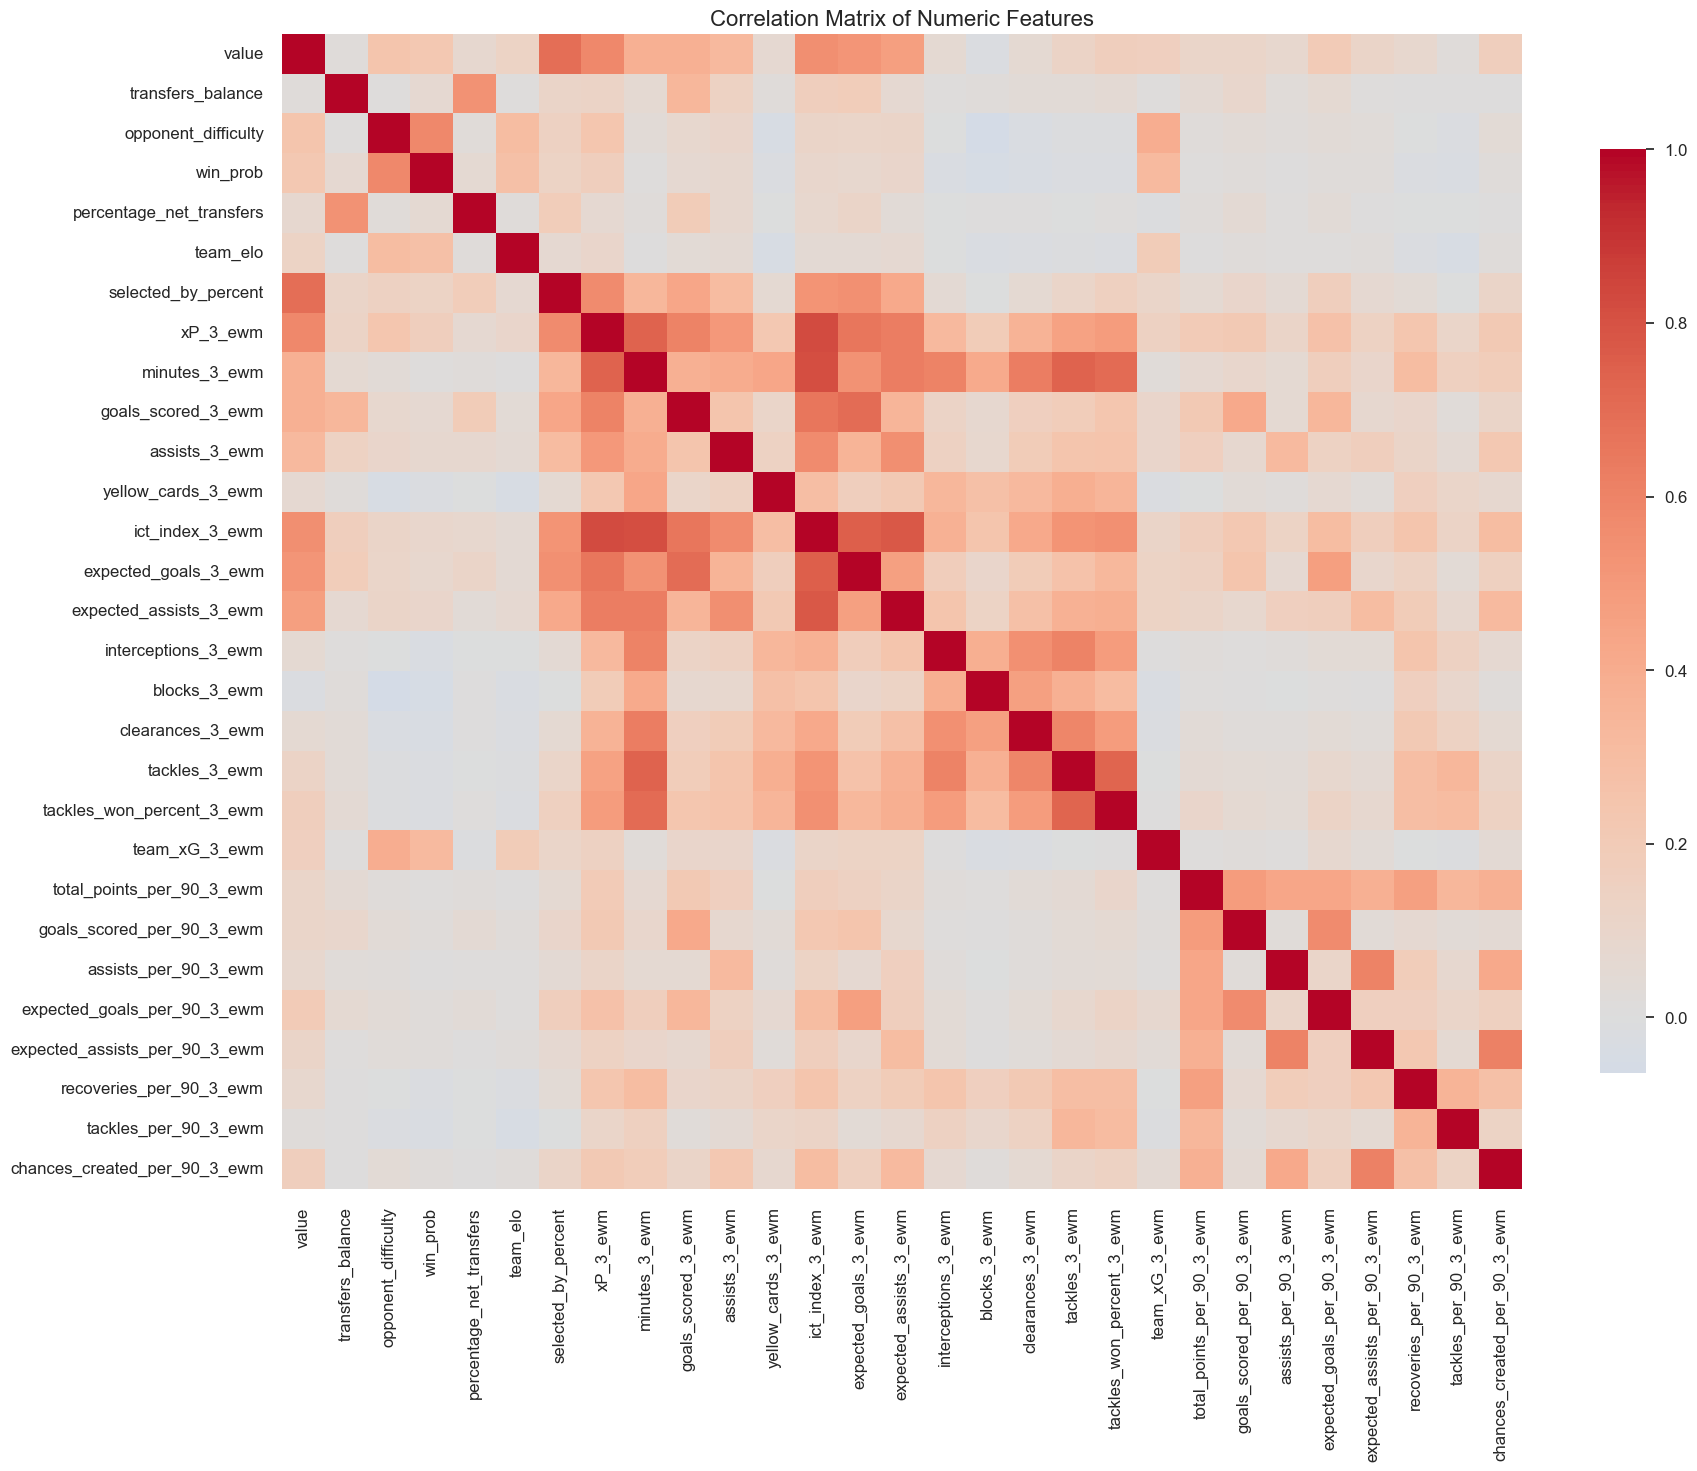

In [56]:
# Select only numeric features (exclude the target 'price')
numeric_df = working_mid_df.select_dtypes(include=['float64', 'int64']).drop(columns=["xP"], errors="ignore")

# Compute correlation matrix
corr_matrix = numeric_df.corr()


# Display full matrix as heatmap
plt.figure(figsize=(20,15))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,   # set to True if you want numbers on cells
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()

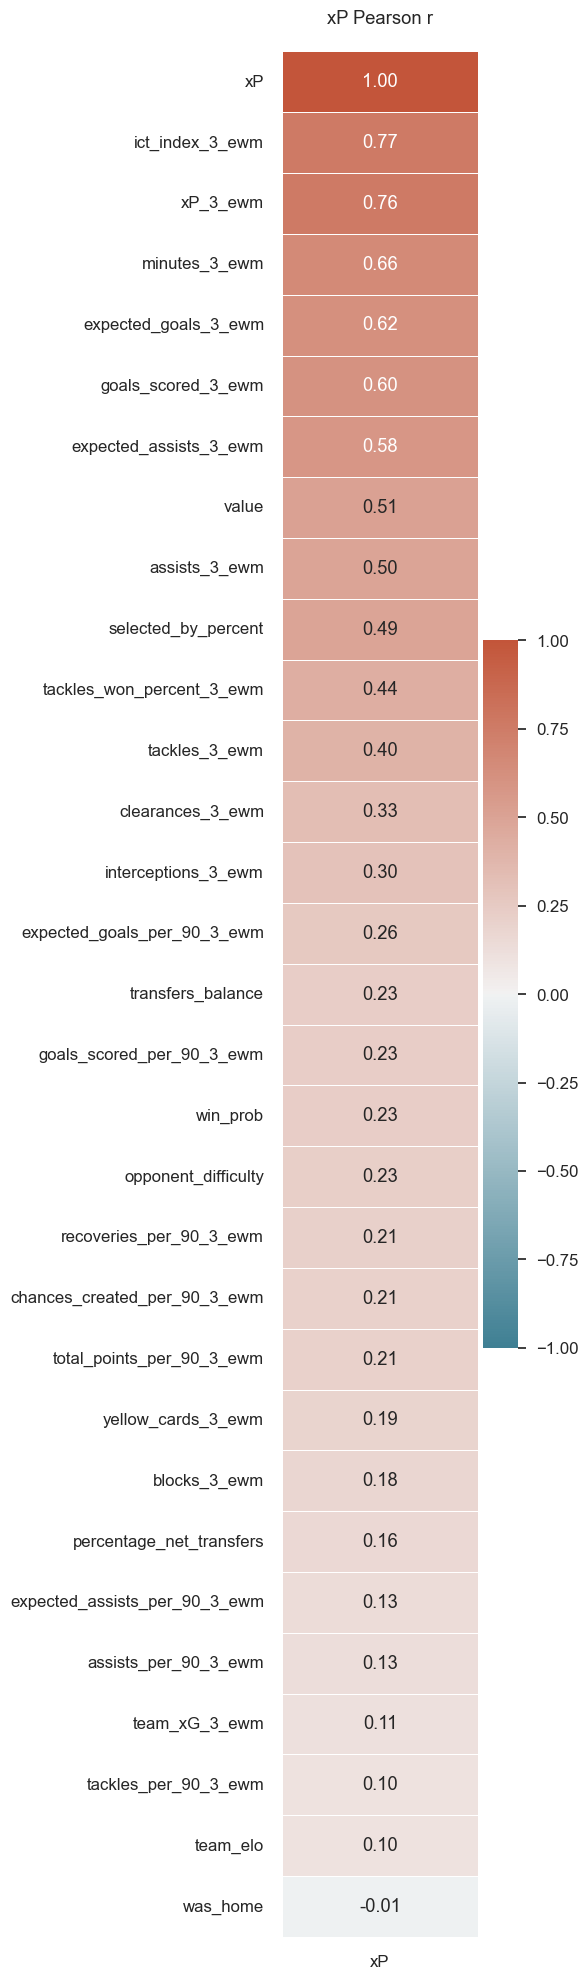

In [57]:

# Compute correlations with price
num_cols = working_mid_df.select_dtypes("number").columns
corr_vec  = working_mid_df[feats_mid].corr(method="pearson")["xP"].sort_values(ascending=False)
sns.set_theme(style="white")
sns.set(font_scale=1.1)
plt.figure(figsize=(6,20))
ax = sns.heatmap(
        corr_vec.to_frame(),
        annot=True, fmt=".2f",
        vmin=-1, vmax=1,
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        center=0,
        linewidths=.5, linecolor="white",
        cbar_kws={"shrink":0.8, "pad":0.02}
     )
ax.set_title("xP Pearson r", pad=20)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [58]:
final_mid_data = working_mid_df[feats_mid]
final_mid_data[['round', 'element', 'was_home']] = mid_data[['round', 'element','was_home']]
# Convert boolean to integer (True -> 1, False -> 0)
final_mid_data["was_home"] = final_mid_data["was_home"].astype(int)
final_mid_data = final_mid_data.fillna(0)
final_mid_data

,xP,was_home,value,transfers_balance,opponent_difficulty,win_prob,percentage_net_transfers,team_elo,selected_by_percent,xP_3_ewm,...,total_points_per_90_3_ewm,goals_scored_per_90_3_ewm,assists_per_90_3_ewm,expected_goals_per_90_3_ewm,expected_assists_per_90_3_ewm,recoveries_per_90_3_ewm,tackles_per_90_3_ewm,chances_created_per_90_3_ewm,round,element
0,2.3,1,55.0,0.0,5.0,0.801,0.000000,1946.90,0.000000,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
1,0.8,0,55.0,-790.0,5.0,0.536,0.000000,1988.36,0.000357,2.3000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,1
2,0.0,1,54.0,-279.0,5.0,0.715,-0.000010,1956.94,0.000347,1.5500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,1
3,0.0,0,54.0,-747.0,5.0,0.413,-0.000129,1985.78,0.000218,0.7750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,1
4,0.0,0,54.0,-174.0,5.0,0.211,-0.000046,1990.55,0.000173,0.3875,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26908,-0.5,0,45.0,29.0,2.0,0.143,0.000003,1585.93,0.000003,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35,800
26909,-0.5,1,45.0,28.0,2.0,0.189,0.000003,1610.27,0.000006,-0.2500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36,800
26910,0.0,0,45.0,17.0,2.0,0.326,0.000003,1580.44,0.000009,-0.3750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37,800
26911,-0.5,1,45.0,75.0,2.0,0.317,0.000010,0.00,0.000019,-0.1875,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38,800


## Baseline Model


In [65]:
scaler = StandardScaler()


mid_df = final_mid_data[(final_mid_data['minutes_3_ewm'] > 15)]
mid_df


,xP,was_home,value,transfers_balance,opponent_difficulty,win_prob,percentage_net_transfers,team_elo,selected_by_percent,xP_3_ewm,...,total_points_per_90_3_ewm,goals_scored_per_90_3_ewm,assists_per_90_3_ewm,expected_goals_per_90_3_ewm,expected_assists_per_90_3_ewm,recoveries_per_90_3_ewm,tackles_per_90_3_ewm,chances_created_per_90_3_ewm,round,element
226,0.5,0,49.0,-91.0,5.0,0.211,-0.000389,1990.55,0.003366,1.450000,...,1.000000,0.0,0.0,0.000000,0.000000,2.500000,0.500000,0.000000,5,7
227,2.2,1,49.0,-1446.0,5.0,0.817,-0.000262,1963.00,0.003104,0.975000,...,0.500000,0.0,0.0,0.000000,0.000000,1.250000,0.250000,0.000000,6,7
229,1.7,0,48.0,-353.0,5.0,0.570,-0.000016,2003.65,0.002827,2.043750,...,1.625000,0.0,0.0,0.030000,0.105000,4.812500,0.812500,0.750000,8,7
230,0.7,1,48.0,-624.0,5.0,0.380,-0.000079,1971.06,0.002748,1.871875,...,0.812500,0.0,0.0,0.015000,0.052500,2.406250,0.406250,0.375000,9,7
234,1.5,0,47.0,-404.0,5.0,0.654,0.000183,1999.20,0.003039,0.910742,...,0.050781,0.0,0.0,0.000937,0.121406,3.962891,0.025391,1.023438,13,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26612,0.0,0,50.0,-42.0,3.0,0.288,-0.000004,1773.47,0.000116,0.757031,...,3.039860,0.0,0.0,0.017398,0.105944,3.933661,0.130814,1.406250,32,772
26615,1.0,0,50.0,19.0,3.0,0.211,-0.000008,1745.25,0.000135,0.219629,...,4.014598,0.0,0.0,0.106021,0.381897,2.741708,2.958659,2.252704,35,772
26616,1.0,1,50.0,33.0,3.0,0.516,0.000008,1790.89,0.000143,0.609814,...,5.221585,0.0,0.0,0.053010,0.223091,1.370854,1.479330,1.126352,36,772
26617,1.0,0,50.0,-32.0,3.0,0.263,0.000003,1742.29,0.000147,0.804907,...,5.423292,0.0,0.0,0.026505,0.308421,0.685427,3.552165,6.188176,37,772


In [72]:
mid_y = mid_df['xP']
mid_X = mid_df.drop(columns=['xP'])
mid_X

,was_home,value,transfers_balance,opponent_difficulty,win_prob,percentage_net_transfers,team_elo,selected_by_percent,xP_3_ewm,minutes_3_ewm,...,total_points_per_90_3_ewm,goals_scored_per_90_3_ewm,assists_per_90_3_ewm,expected_goals_per_90_3_ewm,expected_assists_per_90_3_ewm,recoveries_per_90_3_ewm,tackles_per_90_3_ewm,chances_created_per_90_3_ewm,round,element
226,0,49.0,-91.0,5.0,0.211,-0.000389,1990.55,0.003366,1.450000,45.000000,...,1.000000,0.0,0.0,0.000000,0.000000,2.500000,0.500000,0.000000,5,7
227,1,49.0,-1446.0,5.0,0.817,-0.000262,1963.00,0.003104,0.975000,22.500000,...,0.500000,0.0,0.0,0.000000,0.000000,1.250000,0.250000,0.000000,6,7
229,0,48.0,-353.0,5.0,0.570,-0.000016,2003.65,0.002827,2.043750,35.625000,...,1.625000,0.0,0.0,0.030000,0.105000,4.812500,0.812500,0.750000,8,7
230,1,48.0,-624.0,5.0,0.380,-0.000079,1971.06,0.002748,1.871875,17.812500,...,0.812500,0.0,0.0,0.015000,0.052500,2.406250,0.406250,0.375000,9,7
234,0,47.0,-404.0,5.0,0.654,0.000183,1999.20,0.003039,0.910742,24.113281,...,0.050781,0.0,0.0,0.000937,0.121406,3.962891,0.025391,1.023438,13,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26612,0,50.0,-42.0,3.0,0.288,-0.000004,1773.47,0.000116,0.757031,17.882812,...,3.039860,0.0,0.0,0.017398,0.105944,3.933661,0.130814,1.406250,32,772
26615,0,50.0,19.0,3.0,0.211,-0.000008,1745.25,0.000135,0.219629,35.360352,...,4.014598,0.0,0.0,0.106021,0.381897,2.741708,2.958659,2.252704,35,772
26616,1,50.0,33.0,3.0,0.516,0.000008,1790.89,0.000143,0.609814,24.680176,...,5.221585,0.0,0.0,0.053010,0.223091,1.370854,1.479330,1.126352,36,772
26617,0,50.0,-32.0,3.0,0.263,0.000003,1742.29,0.000147,0.804907,20.340088,...,5.423292,0.0,0.0,0.026505,0.308421,0.685427,3.552165,6.188176,37,772


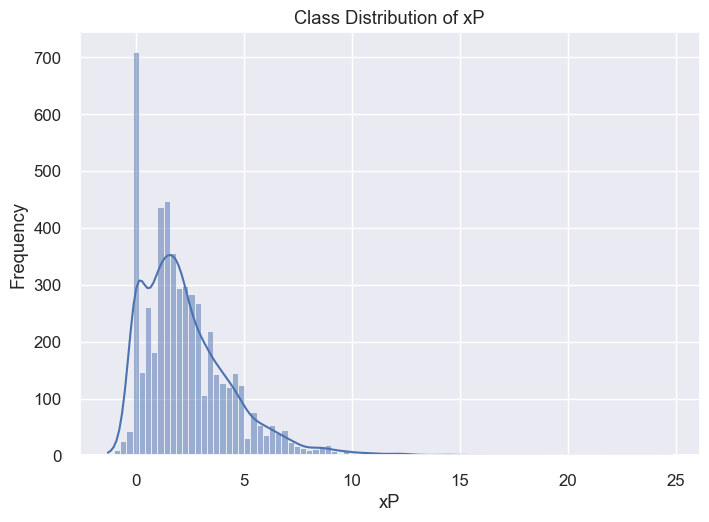

In [67]:
sns.histplot(mid_yr, kde=True)
plt.title('Class Distribution of xP')
plt.xlabel('xP')
plt.ylabel('Frequency')
plt.show()

<Axes: ylabel='Count'>

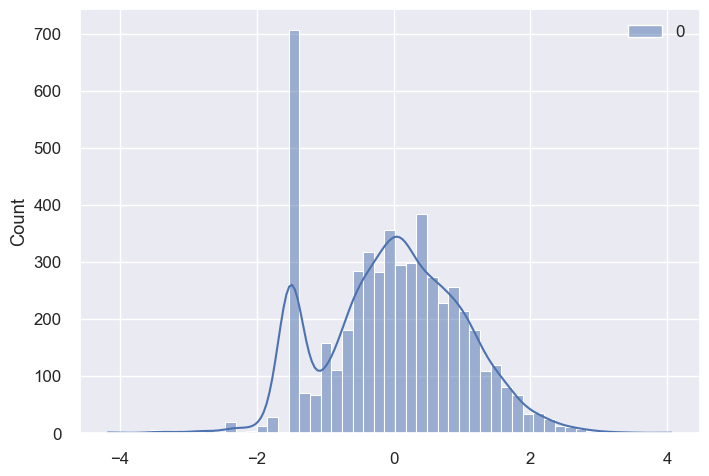

In [68]:
pt_xp = PowerTransformer(method='yeo-johnson', standardize=True)
v = pt_xp.fit_transform(mid_y.values.reshape(-1,1))

sns.histplot(v, kde=True)

In [ ]:
"""
Compare multiple regression models for predicting FPL xP, using a
chronological (round-based) train/test split to avoid look-ahead leakage.

Assumes `mid_df` is a DataFrame with columns including:
    'xP', 'round', 'element', <feature columns...>
"""

import numpy as np
import pandas as pd
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional libraries — only used if installed
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False


# --------------------------------------------------------------------------
# 1. Chronological split
# --------------------------------------------------------------------------
def chronological_split(df, gw, target_col="xP", drop_cols=("xP", "round", "element")):
    """Train on rounds < gw, test on round == gw. No random shuffling —
    this mirrors how the model will actually be used (predict an unseen
    upcoming gameweek from past ones)."""
    df_train = df[df["round"] < gw]
    df_test = df[df["round"] == gw]


    if df_train.empty or df_test.empty:
        raise ValueError(f"Empty train or test split for gw={gw}. Check round range.")

    y_train = df_train[target_col]
    y_test = df_test[target_col]
    X_train = df_train.drop(columns=list(drop_cols))
    X_test = df_test.drop(columns=list(drop_cols))

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_test_scaled, y_train, y_test


# --------------------------------------------------------------------------
# 2. Model zoo
# --------------------------------------------------------------------------
def build_models(random_state=42):
    """Each model is wrapped in TransformedTargetRegressor(log1p/expm1).
    A shift constant `c` is applied upstream in evaluate_all() so that
    the target is guaranteed positive before log1p is applied."""
    models = {
        "HistGradientBoosting": HistGradientBoostingRegressor(random_state=random_state),
        "RandomForest": RandomForestRegressor(
            n_estimators=300, max_depth=None, random_state=random_state, n_jobs=-1
        ),
        "GradientBoosting": GradientBoostingRegressor(random_state=random_state),
        "Ridge": Ridge(alpha=1.0)
    }
    if HAS_XGB:
        models["XGBoost"] = XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            random_state=random_state, n_jobs=-1, verbosity=0,
        )
    if HAS_LGBM:
        models["LightGBM"] = LGBMRegressor(
            n_estimators=300, random_state=random_state, n_jobs=-1, verbosity=-1
        )
    return models


# --------------------------------------------------------------------------
# 3. Evaluate all models on one chronological split
# --------------------------------------------------------------------------
def evaluate_all(df, gw, target_col="xP", drop_cols=("xP", "round", "element"),
                  use_log_transform=True, verbose=True):
    X_train, X_test, y_train, y_test = chronological_split(df, gw, target_col, drop_cols)

    # Shift constant computed from TRAIN only (avoids test-set leakage).
    # Buffer of 1.0 instead of 0.1 gives more headroom near the log1p boundary.
    c = abs(y_train.min()) + 1.0 if use_log_transform else 0.0
    y_train_shifted = y_train + c

    results = []
    fitted_models = {}

    for name, base_model in build_models().items():
        if use_log_transform:
            model = TransformedTargetRegressor(
                regressor=base_model, func=np.log1p, inverse_func=np.expm1
            )
        else:
            model = base_model

        try:
            model.fit(X_train, y_train_shifted if use_log_transform else y_train)
            preds = model.predict(X_test)
            preds_original = preds - c if use_log_transform else preds
        except Exception as e:
            if verbose:
                print(f"[{name}] failed: {e}")
            continue

        mae = mean_absolute_error(y_test, preds_original)
        rmse = np.sqrt(mean_squared_error(y_test, preds_original))
        r2 = r2_score(y_test, preds_original)

        results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
        fitted_models[name] = model

        if verbose:
            print(f"{name:>22s} | MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

    results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
    return results_df, fitted_models


# --------------------------------------------------------------------------
# 4. (Optional) evaluate across several gameweeks and average
# --------------------------------------------------------------------------
def evaluate_across_gws(df, gw_list, **kwargs):
    """Run evaluate_all() for each gw in gw_list and return per-gw results
    plus a summary averaged across gameweeks. Useful because a single
    train/test split can be noisy — averaging over several rounds gives
    a more stable comparison between models."""
    all_rows = []
    for gw in gw_list:
        try:
            res, _ = evaluate_all(df, gw, verbose=False, **kwargs)
        except ValueError as e:
            print(f"Skipping gw={gw}: {e}")
            continue
        res["gw"] = gw
        all_rows.append(res)

    if not all_rows:
        raise ValueError("No valid gameweeks evaluated.")

    combined = pd.concat(all_rows, ignore_index=True)
    summary = (
        combined.groupby("model")[["MAE", "RMSE", "R2"]]
        .mean()
        .sort_values("MAE")
        .reset_index()
    )
    return combined, summary




"""
Hyperparameter-tune whichever model came out on top in evaluate_across_gws()
(from compare_models.py), using CV folds that respect gameweek order —
no random K-fold, since that would let future rounds leak into training
during the search itself.

Usage:
    from compare_models import evaluate_across_gws
    combined, summary = evaluate_across_gws(mid_df, gw_list=range(4, 9))

    best_model, search = tune_best_model(
        mid_df, summary, val_gws=range(4, 9), final_test_gw=9
    )
"""

import numpy as np
import pandas as pd
from scipy.stats import loguniform, uniform, randint
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# --------------------------------------------------------------------------
# 4. Search spaces, keyed by the same names used in build_models()
# --------------------------------------------------------------------------
PARAM_DISTRIBUTIONS = {
    "HistGradientBoosting": {
        "regressor__learning_rate": loguniform(0.01, 0.3),
        "regressor__max_iter": randint(100, 600),
        "regressor__max_leaf_nodes": randint(15, 127),
        "regressor__max_depth": [None, 3, 5, 7, 10],
        "regressor__min_samples_leaf": randint(5, 60),
        "regressor__l2_regularization": loguniform(1e-3, 10),
    },
    "RandomForest": {
        "regressor__n_estimators": randint(100, 600),
        "regressor__max_depth": [None, 5, 10, 20, 30],
        "regressor__min_samples_split": randint(2, 15),
        "regressor__min_samples_leaf": randint(1, 10),
        "regressor__max_features": ["sqrt", "log2", None],
    },
    "GradientBoosting": {
        "regressor__n_estimators": randint(100, 400),
        "regressor__learning_rate": loguniform(0.01, 0.3),
        "regressor__max_depth": randint(2, 6),
        "regressor__subsample": uniform(0.6, 0.4),
        "regressor__min_samples_leaf": randint(1, 20),
    },
    "Ridge": {
        "regressor__alpha": loguniform(0.01, 100),
    },
    "XGBoost": {
        "regressor__n_estimators": randint(100, 600),
        "regressor__max_depth": randint(3, 9),
        "regressor__learning_rate": loguniform(0.01, 0.3),
        "regressor__subsample": uniform(0.6, 0.4),
        "regressor__colsample_bytree": uniform(0.6, 0.4),
        "regressor__reg_alpha": loguniform(1e-3, 10),
        "regressor__reg_lambda": loguniform(1e-3, 10),
    },
    "LightGBM": {
        "regressor__n_estimators": randint(100, 600),
        "regressor__num_leaves": randint(15, 127),
        "regressor__learning_rate": loguniform(0.01, 0.3),
        "regressor__subsample": uniform(0.6, 0.4),
        "regressor__colsample_bytree": uniform(0.6, 0.4),
        "regressor__reg_alpha": loguniform(1e-3, 10),
        "regressor__reg_lambda": loguniform(1e-3, 10),
    },
}

# --------------------------------------------------------------------------
# 5. Chronological CV folds (expanding window over rounds)
# --------------------------------------------------------------------------
def rolling_origin_splits(rounds_array, val_gws):
    """Given the 'round' values aligned positionally with X, build
    (train_idx, test_idx) pairs for each validation gameweek: train on
    everything before it, test on it. Mirrors how the model will
    actually be deployed (predict the next unseen gameweek)."""
    rounds_array = np.asarray(rounds_array)
    splits = []
    for gw in val_gws:
        train_idx = np.where(rounds_array < gw)[0]
        test_idx = np.where(rounds_array == gw)[0]
        if len(train_idx) == 0 or len(test_idx) == 0:
            continue
        splits.append((train_idx, test_idx))
    if not splits:
        raise ValueError("No valid folds — check val_gws against available rounds.")
    return splits

# --------------------------------------------------------------------------
# 6. Tune the best model from the comparison summary
# --------------------------------------------------------------------------
def tune_best_model(
    df,
    summary_df,
    val_gws,
    final_test_gw,
    target_col="xP",
    drop_cols=("xP", "round", "element"),
    n_iter=40,
    random_state=42,
    verbose=True,
):
    best_name = summary_df.sort_values("MAE").iloc[0]["model"]

    if best_name not in PARAM_DISTRIBUTIONS:
        raise ValueError(
            f"No param grid defined for '{best_name}'. "
            f"Add one to PARAM_DISTRIBUTIONS."
        )
    if verbose:
        print(f"Best model from comparison: {best_name}")

    # CV pool = everything strictly before the held-out final test gw
    pool = df[df["round"] < final_test_gw].reset_index(drop=True)
    X_pool = pool.drop(columns=list(drop_cols))
    y_pool = pool[target_col]
    rounds_pool = pool["round"]

    # Shift constant from the CV pool only — final_test_gw stays untouched
    c = abs(y_pool.min()) + 1.0
    y_pool_shifted = y_pool + c

    cv_splits = rolling_origin_splits(rounds_pool, val_gws)

    base_model = build_models(random_state=random_state)[best_name]
    wrapped = TransformedTargetRegressor(
        regressor=base_model, func=np.log1p, inverse_func=np.expm1
    )

    search = RandomizedSearchCV(
        estimator=wrapped,
        param_distributions=PARAM_DISTRIBUTIONS[best_name],
        n_iter=n_iter,
        cv=cv_splits,
        scoring="neg_mean_absolute_error",
        random_state=random_state,
        n_jobs=-1,
        verbose=1 if verbose else 0,
    )
    search.fit(X_pool, y_pool_shifted)

    if verbose:
        print(f"\nBest CV MAE: {-search.best_score_:.3f}")
        print("Best params:")
        for k, v in search.best_params_.items():
            print(f"  {k}: {v}")

    # Final check: refit best estimator on full pool, evaluate on the
    # untouched holdout gameweek
    X_train_final, X_holdout, y_train_final, y_holdout = chronological_split(
        df, final_test_gw, target_col, drop_cols
    )
    c_final = abs(y_train_final.min()) + 1.0
    best_estimator = search.best_estimator_
    best_estimator.fit(X_train_final, y_train_final + c_final)
    preds = best_estimator.predict(X_holdout) - c_final

    mae = mean_absolute_error(y_holdout, preds)
    rmse = np.sqrt(mean_squared_error(y_holdout, preds))
    r2 = r2_score(y_holdout, preds)

    if verbose:
        print(f"\nHoldout (round {final_test_gw}) performance:")
        print(f"  MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

    return best_name, best_estimator, search, c_final, mae, rmse, r2


In [165]:
models_by_round = {}
mae_by_round = {}

tuned_models = []
for round in range(5, 30):
    # Multi-gameweek comparison (more robust signal, recommended)
    print(f"\n=== Averaged across rounds {3}-{round} ===")

    # Step 1: compare models across several rounds (as before)
    combined, summary = evaluate_across_gws(mid_df, gw_list=range(3,round+1))
    print(summary.to_string(index=False))

    base_name = summary.sort_values("MAE").iloc[0]["model"]
    base_mae = summary.sort_values("MAE").iloc[0]["MAE"]
    # print(f'Best Model -------------->  {best_name} <===> {tuned_models}')
    # if best_name not in tuned_models:

    # Step 2: tune the winner, validating on rounds 6-round, holding out round+1
    best_model, best_estimator, search, c_final, mae, rmse, r2 = tune_best_model(
        mid_df,
        summary,
        val_gws=range(1,round),
        final_test_gw=round+1,
        n_iter=40,
    )

    if mae > base_mae:
        # mae_by_round[round+1] = mae
        models_by_round[round+1] = {
            'mae': mae,
            "best_model": best_model,
            "c_final": c_final,
            "best_estimator": best_estimator,
            "search": search
        }
    else:
        mae_by_round[round+1] = base_mae
        models_by_round[round+1] = {
            'mae': base_mae,
            "best_model": base_name,
            "c_final": c_final
        }
    # tuned_models.append(best_name)


=== Averaged across rounds 3-5 ===
               model      MAE     RMSE       R2
        RandomForest 0.778140 1.067277 0.741363
             XGBoost 0.806152 1.128118 0.712614
    GradientBoosting 0.808254 1.084532 0.734078
HistGradientBoosting 0.860198 1.142866 0.704141
            LightGBM 0.869900 1.165119 0.692568
               Ridge 0.917248 1.531936 0.455102
Best model from comparison: RandomForest
Fitting 2 folds for each of 40 candidates, totalling 80 fits

Best CV MAE: 0.785
Best params:
  regressor__max_depth: 10
  regressor__max_features: sqrt
  regressor__min_samples_leaf: 2
  regressor__min_samples_split: 3
  regressor__n_estimators: 319

Holdout (round 6) performance:
  MAE=0.793  RMSE=1.162  R2=0.688

=== Averaged across rounds 3-6 ===
               model      MAE     RMSE       R2
        RandomForest 0.780885 1.087968 0.729560
             XGBoost 0.799623 1.129080 0.710383
    GradientBoosting 0.801886 1.095987 0.726692
HistGradientBoosting 0.829692 1.126186 0.7

In [166]:
models_by_round

{6: {'mae': 0.79320759343032,
  'best_model': 'RandomForest',
  'c_final': 2.0,
  'best_estimator': TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                             regressor=RandomForestRegressor(max_depth=10,
                                                             max_features='sqrt',
                                                             min_samples_leaf=2,
                                                             min_samples_split=3,
                                                             n_estimators=319,
                                                             n_jobs=-1,
                                                             random_state=42)),
  'search': RandomizedSearchCV(cv=[(array([  1,   5,   9,  13,  17,  21,  28,  34,  38,  42,  46,  50,  54,
          58,  62,  66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106,
         110, 115, 121, 125, 129, 133, 137, 140, 144, 146, 150, 158, 161,
         167, 

In [ ]:
"""
Hyperparameter-tune whichever model came out on top in evaluate_across_gws()
(from compare_models.py), using CV folds that respect gameweek order —
no random K-fold, since that would let future rounds leak into training
during the search itself.

Usage:
    from compare_models import evaluate_across_gws
    combined, summary = evaluate_across_gws(mid_df, gw_list=range(4, 9))

    best_model, search = tune_best_model(
        mid_df, summary, val_gws=range(4, 9), final_test_gw=9
    )
"""

import numpy as np
import pandas as pd
from scipy.stats import loguniform, uniform, randint
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# from compare_models import build_models, chronological_split


# --------------------------------------------------------------------------
# 1. Search spaces, keyed by the same names used in build_models()
# --------------------------------------------------------------------------
PARAM_DISTRIBUTIONS = {
    "HistGradientBoosting": {
        "regressor__learning_rate": loguniform(0.01, 0.3),
        "regressor__max_iter": randint(100, 600),
        "regressor__max_leaf_nodes": randint(15, 127),
        "regressor__max_depth": [None, 3, 5, 7, 10],
        "regressor__min_samples_leaf": randint(5, 60),
        "regressor__l2_regularization": loguniform(1e-3, 10),
    },
    "RandomForest": {
        "regressor__n_estimators": randint(100, 600),
        "regressor__max_depth": [None, 5, 10, 20, 30],
        "regressor__min_samples_split": randint(2, 15),
        "regressor__min_samples_leaf": randint(1, 10),
        "regressor__max_features": ["sqrt", "log2", None],
    },
    "GradientBoosting": {
        "regressor__n_estimators": randint(100, 400),
        "regressor__learning_rate": loguniform(0.01, 0.3),
        "regressor__max_depth": randint(2, 6),
        "regressor__subsample": uniform(0.6, 0.4),
        "regressor__min_samples_leaf": randint(1, 20),
    },
    "Ridge": {
        "regressor__alpha": loguniform(0.01, 100),
    },
    "ElasticNet": {
        "regressor__alpha": loguniform(0.001, 10),
        "regressor__l1_ratio": uniform(0, 1),
    },
    "XGBoost": {
        "regressor__n_estimators": randint(100, 600),
        "regressor__max_depth": randint(3, 9),
        "regressor__learning_rate": loguniform(0.01, 0.3),
        "regressor__subsample": uniform(0.6, 0.4),
        "regressor__colsample_bytree": uniform(0.6, 0.4),
        "regressor__reg_alpha": loguniform(1e-3, 10),
        "regressor__reg_lambda": loguniform(1e-3, 10),
    },
    "LightGBM": {
        "regressor__n_estimators": randint(100, 600),
        "regressor__num_leaves": randint(15, 127),
        "regressor__learning_rate": loguniform(0.01, 0.3),
        "regressor__subsample": uniform(0.6, 0.4),
        "regressor__colsample_bytree": uniform(0.6, 0.4),
        "regressor__reg_alpha": loguniform(1e-3, 10),
        "regressor__reg_lambda": loguniform(1e-3, 10),
    },
}


# --------------------------------------------------------------------------
# 2. Chronological CV folds (expanding window over rounds)
# --------------------------------------------------------------------------
def rolling_origin_splits(rounds_array, val_gws):
    """Given the 'round' values aligned positionally with X, build
    (train_idx, test_idx) pairs for each validation gameweek: train on
    everything before it, test on it. Mirrors how the model will
    actually be deployed (predict the next unseen gameweek)."""
    rounds_array = np.asarray(rounds_array)
    splits = []
    for gw in val_gws:
        train_idx = np.where(rounds_array < gw)[0]
        test_idx = np.where(rounds_array == gw)[0]
        if len(train_idx) == 0 or len(test_idx) == 0:
            continue
        splits.append((train_idx, test_idx))
    if not splits:
        raise ValueError("No valid folds — check val_gws against available rounds.")
    return splits


# --------------------------------------------------------------------------
# 3. Tune the best model from the comparison summary
# --------------------------------------------------------------------------
def tune_best_model(
    df,
    summary_df=None,
    model_name=None,
    val_gws=None,
    final_test_gw=None,
    target_col="xP",
    drop_cols=("xP", "round", "element"),
    n_iter=40,
    random_state=42,
    verbose=True,
):
    """Tune a single model type. Pass either `summary_df` (picks the top
    row by MAE — this is the default-hyperparameter winner) or an explicit
    `model_name` (use this when comparing multiple *tuned* models against
    each other, since the untuned winner isn't necessarily the tuned winner)."""
    if model_name is None:
        if summary_df is None:
            raise ValueError("Provide either `summary_df` or `model_name`.")
        model_name = summary_df.sort_values("MAE").iloc[0]["model"]
    best_name = model_name
    if best_name not in PARAM_DISTRIBUTIONS:
        raise ValueError(
            f"No param grid defined for '{best_name}'. "
            f"Add one to PARAM_DISTRIBUTIONS."
        )
    if verbose:
        print(f"Tuning: {best_name}")

    # CV pool = everything strictly before the held-out final test gw
    pool = df[df["round"] < final_test_gw].reset_index(drop=True)
    X_pool = pool.drop(columns=list(drop_cols))
    y_pool = pool[target_col]
    rounds_pool = pool["round"]

    # Shift constant from the CV pool only — final_test_gw stays untouched
    c = abs(y_pool.min()) + 1.0
    y_pool_shifted = y_pool + c

    cv_splits = rolling_origin_splits(rounds_pool, val_gws)

    base_model = build_models(random_state=random_state)[best_name]
    wrapped = TransformedTargetRegressor(
        regressor=base_model, func=np.log1p, inverse_func=np.expm1
    )

    search = RandomizedSearchCV(
        estimator=wrapped,
        param_distributions=PARAM_DISTRIBUTIONS[best_name],
        n_iter=n_iter,
        cv=cv_splits,
        scoring="neg_mean_absolute_error",
        random_state=random_state,
        n_jobs=-1,
        verbose=1 if verbose else 0,
    )
    search.fit(X_pool, y_pool_shifted)

    if verbose:
        print(f"\nBest CV MAE: {-search.best_score_:.3f}")
        print("Best params:")
        for k, v in search.best_params_.items():
            print(f"  {k}: {v}")

    # Final check: refit best estimator on full pool, evaluate on the
    # untouched holdout gameweek
    X_train_final, X_holdout, y_train_final, y_holdout = chronological_split(
        df, final_test_gw, target_col, drop_cols
    )
    c_final = abs(y_train_final.min()) + 1.0
    best_estimator = search.best_estimator_
    best_estimator.fit(X_train_final, y_train_final + c_final)
    preds = best_estimator.predict(X_holdout) - c_final

    mae = mean_absolute_error(y_holdout, preds)
    rmse = np.sqrt(mean_squared_error(y_holdout, preds))
    r2 = r2_score(y_holdout, preds)

    if verbose:
        print(f"\nHoldout (round {final_test_gw}) performance:")
        print(f"  MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

    return best_name, best_estimator, search, c_final, mae, rmse, r2


# --------------------------------------------------------------------------
# 4. Tune every model type, then pick the winner from TUNED performance
#    (rather than picking the winner from default-hyperparameter performance
#    and only tuning that one). Much more expensive: n_iter searches x
#    however many model types you have, instead of just one.
# --------------------------------------------------------------------------
def tune_all_models(
    df,
    val_gws,
    final_test_gw,
    model_names=None,
    target_col="xP",
    drop_cols=("xP", "round", "element"),
    n_iter=40,
    random_state=42,
    verbose=True,
):
    if model_names is None:
        model_names = list(PARAM_DISTRIBUTIONS.keys())

    all_results = {}
    rows = []

    for name in model_names:
        if verbose:
            print(f"\n{'=' * 50}\nTuning {name}\n{'=' * 50}")
        try:
            best_name, best_estimator, search, c_final, mae, rmse, r2 = tune_best_model(
                df,
                model_name=name,
                val_gws=val_gws,
                final_test_gw=final_test_gw,
                target_col=target_col,
                drop_cols=drop_cols,
                n_iter=n_iter,
                random_state=random_state,
                verbose=verbose,
            )
        except Exception as e:
            if verbose:
                print(f"[{name}] tuning failed: {e}")
            continue

        all_results[name] = {
            "best_estimator": best_estimator,
            "search": search,
            "c_final": c_final,
        }
        rows.append({
            "model": name,
            "cv_mae": -search.best_score_,   # CV score used to pick hyperparams
            "holdout_mae": mae,              # score on the untouched final_test_gw
            "holdout_rmse": rmse,
            "holdout_r2": r2,
        })

    if not rows:
        raise ValueError("No models tuned successfully.")

    leaderboard = pd.DataFrame(rows).sort_values("holdout_mae").reset_index(drop=True)
    winner_name = leaderboard.iloc[0]["model"]

    if verbose:
        print(f"\n{'=' * 50}\nLeaderboard (tuned models, by holdout MAE)\n{'=' * 50}")
        print(leaderboard.to_string(index=False))
        print(f"\nWinner after tuning: {winner_name}")

    return winner_name, all_results[winner_name], leaderboard, all_results


def build_tuned_estimator(model_name, best_params, random_state=42):
    """Reconstruct a fresh (unfit) estimator with previously-found best
    params, so it can be refit on updated training data without re-running
    the search."""
    base_model = build_models(random_state=random_state)[model_name]
    wrapped = TransformedTargetRegressor(
        regressor=base_model, func=np.log1p, inverse_func=np.expm1
    )
    wrapped.set_params(**best_params)
    return wrapped


def get_or_tune_model(
    df,
    model_name,
    val_gws,
    final_test_gw,
    cache,
    target_col="xP",
    drop_cols=("xP", "round", "element"),
    n_iter=40,
    random_state=42,
    force_retune=False,
    verbose=True,
):
    """Check `cache` (a dict you own and pass in each round) for this
    model's best params. If present and `force_retune=False`, skip the
    search entirely and just refit those params on the current training
    window. Otherwise run the full search and store the result in `cache`
    for next time."""
    if not force_retune and model_name in cache:
        if verbose:
            print(f"[{model_name}] using cached params (skipping search)")
        best_params = cache[model_name]["best_params"]
        estimator = build_tuned_estimator(model_name, best_params, random_state)

        X_train, X_holdout, y_train, y_holdout = chronological_split(
            df, final_test_gw, target_col, drop_cols
        )
        c_final = abs(y_train.min()) + 1.0
        estimator.fit(X_train, y_train + c_final)
        preds = estimator.predict(X_holdout) - c_final

        mae = mean_absolute_error(y_holdout, preds)
        rmse = np.sqrt(mean_squared_error(y_holdout, preds))
        r2 = r2_score(y_holdout, preds)

        if verbose:
            print(f"  Holdout (round {final_test_gw}): MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

        return model_name, estimator, None, c_final, mae, rmse, r2  # search=None: no search ran

    # Cache miss, or a forced refresh — run the full search
    if verbose:
        reason = "forced refresh" if force_retune and model_name in cache else "no cache entry"
        print(f"[{model_name}] running full search ({reason})")

    result = tune_best_model(
        df,
        model_name=model_name,
        val_gws=val_gws,
        final_test_gw=final_test_gw,
        target_col=target_col,
        drop_cols=drop_cols,
        n_iter=n_iter,
        random_state=random_state,
        verbose=verbose,
    )
    best_name, best_estimator, search, c_final, mae, rmse, r2 = result
    cache[model_name] = {
        "best_params": search.best_params_,
        "tuned_at_round": final_test_gw,
        "cv_mae": -search.best_score_,
    }
    return result


# --------------------------------------------------------------------------
# 5. Example usage
# --------------------------------------------------------------------------
if __name__ == "__main__":
    # Option A: pick winner from DEFAULT-hyperparameter comparison,
    # tune only that one (cheap, but the untuned winner may not be the
    # true best after tuning).
    # from compare_models import evaluate_across_gws

    combined, summary = evaluate_across_gws(mid_df, gw_list=range(4, 9))
    print(summary.to_string(index=False))

    best_name, best_estimator, search, c_final, mae, rmse, r2 = tune_best_model(
        mid_df,
        summary_df=summary,
        val_gws=range(4, 9),
        final_test_gw=9,
        n_iter=40,
    )

    # # Option B: tune EVERY model type, pick the winner from TUNED
    # # performance instead (expensive: n_iter searches x every model type).
    # winner_name, winner_result, leaderboard, all_results = tune_all_models(
    #     mid_df,
    #     val_gws=range(4, 9),
    #     final_test_gw=9,
    #     n_iter=40,
    # )

               model      MAE     RMSE       R2
    GradientBoosting 0.747812 1.036215 0.739237
             XGBoost 0.748147 1.033134 0.740520
HistGradientBoosting 0.761354 1.035973 0.738425
        RandomForest 0.764315 1.053681 0.729307
            LightGBM 0.776803 1.056283 0.728600
          ElasticNet 0.839817 1.161309 0.671231
               Ridge 0.880881 1.376061 0.522753
Tuning: GradientBoosting
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV MAE: 0.726
Best params:
  regressor__learning_rate: 0.02545642421255076
  regressor__max_depth: 4
  regressor__min_samples_leaf: 1
  regressor__n_estimators: 326
  regressor__subsample: 0.6478376983753207

Holdout (round 9) performance:
  MAE=0.863  RMSE=1.277  R2=0.503

Tuning HistGradientBoosting
Tuning: HistGradientBoosting
Fitting 5 folds for each of 40 candidates, totalling 200 fits


KeyboardInterrupt: 

In [156]:
# from compare_models import evaluate_across_gws
# from hyperparameter_tuning import get_or_tune_model

results = {}
mae_by_round = {}
param_cache = {}          # persists across rounds: {model_name: {"best_params": ..., ...}}

RETUNE_EVERY = 5          # force a fresh search every N rounds, per model
VALIDATION_WINDOW = 6     # rolling window instead of ever-expanding range(3, round_)

for round_ in range(5, 30):
    print(f"\n=== Round {round_} ===")

    val_start = max(3, round_ - VALIDATION_WINDOW)
    combined, summary = evaluate_across_gws(mid_df, gw_list=range(val_start, round_ + 1))
    print(summary.to_string(index=False))

    winner_name = summary.sort_values("MAE").iloc[0]["model"]

    force = (round_ % RETUNE_EVERY == 0) or (winner_name not in param_cache)

    best_name, best_estimator, search, c_final, mae_val, rmse, r2 = get_or_tune_model(
        mid_df,
        model_name=winner_name,
        val_gws=range(val_start, round_),
        final_test_gw=round_ + 1,
        cache=param_cache,
        n_iter=40,
        force_retune=force,
    )

    mae_by_round[round_ + 1] = mae_val
    results[round_ + 1] = {
        "best_model": best_name,
        "best_estimator": best_estimator,
        "c_final": c_final,
        "search": search,          # None on cache-hit rounds
        "was_retuned": force,
        "mae": mae_val,
        "rmse": rmse,
        "r2": r2,
    }

import pandas as pd
mae_trend = pd.Series(mae_by_round, name="MAE").sort_index()
print("\nHoldout MAE by round:")
print(mae_trend.to_string())

print("\nFinal cached params per model:")
for name, entry in param_cache.items():
    print(f"{name}: tuned at round {entry['tuned_at_round']}, cv_mae={entry['cv_mae']:.3f}")
    for k, v in entry["best_params"].items():
        print(f"    {k}: {v}")


=== Round 5 ===
               model      MAE     RMSE         R2
        RandomForest 0.778140 1.067277   0.741363
             XGBoost 0.806152 1.128118   0.712614
    GradientBoosting 0.808254 1.084532   0.734078
HistGradientBoosting 0.860198 1.142866   0.704141
            LightGBM 0.869900 1.165119   0.692568
               Ridge 0.917248 1.531936   0.455102
          ElasticNet 1.573492 9.734171 -45.077779
[RandomForest] running full search (no cache entry)
Tuning: RandomForest
Fitting 2 folds for each of 40 candidates, totalling 80 fits

Best CV MAE: 0.785
Best params:
  regressor__max_depth: 10
  regressor__max_features: sqrt
  regressor__min_samples_leaf: 2
  regressor__min_samples_split: 3
  regressor__n_estimators: 319

Holdout (round 6) performance:
  MAE=0.793  RMSE=1.162  R2=0.688

=== Round 6 ===
               model      MAE     RMSE         R2
        RandomForest 0.780885 1.087968   0.729560
             XGBoost 0.799623 1.129080   0.710383
    GradientBoosting 0.801

KeyboardInterrupt: 

## Pycaret


In [ ]:

models_mid = {}
for i in [6, 10, 20, 30]:
    train_data = final_mid_data[(final_mid_data['round'] < i) & (final_mid_data['minutes_5_ewm'] > 15)][feats_mid]
    test_data = final_mid_data[final_mid_data['round'] == i][feats_mid]

    y_train = train_data['xP']
    X_train = train_data.drop(columns='xP')

    y_test = test_data['xP']
    X_test = test_data.drop(columns='xP')


    print(f'Modelling for gameweek {i}')
    model = setup(train_data, target = 'xP', train_size=0.8, session_id=42)

    model_best = model.compare_models(sort='MAE', n_select=1)

    models[i] = model_best


Modelling for gameweek 6


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(92, 14)"
4,Transformed data shape,"(92, 14)"
5,Transformed train set shape,"(73, 14)"
6,Transformed test set shape,"(19, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,1.0171,1.8576,1.3111,0.2362,0.3437,0.5409,0.0100
huber,Huber Regressor,1.0398,1.9071,1.3394,0.2757,0.3612,0.5026,0.0160
lr,Linear Regression,1.0577,1.9199,1.3394,0.2149,0.3525,0.5622,0.3640
br,Bayesian Ridge,1.0731,1.9183,1.3238,0.1939,0.3510,0.5995,0.0110
et,Extra Trees Regressor,1.1157,2.0109,1.3939,0.1812,0.3691,0.6086,0.0360
ada,AdaBoost Regressor,1.1335,1.9308,1.3731,0.2310,0.3892,0.7290,0.0300
rf,Random Forest Regressor,1.1596,2.0382,1.4078,0.1897,0.3858,0.6436,0.0530
en,Elastic Net,1.1689,2.1579,1.4181,0.1261,0.3771,0.7439,0.0090
gbr,Gradient Boosting Regressor,1.2107,2.5184,1.5535,-0.0140,0.3963,0.5819,0.0210
lasso,Lasso Regression,1.2353,2.3183,1.4754,0.1045,0.3928,0.8202,0.2410


Modelling for gameweek 10


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(186, 14)"
4,Transformed data shape,"(186, 14)"
5,Transformed train set shape,"(148, 14)"
6,Transformed test set shape,"(38, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


...

,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(435, 14)"
4,Transformed data shape,"(435, 14)"
5,Transformed train set shape,"(348, 14)"
6,Transformed test set shape,"(87, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.7788,1.0698,1.0192,0.6725,0.3226,0.4992,0.0070
lr,Linear Regression,0.7803,1.0702,1.0195,0.6722,0.3234,0.4998,0.0060
br,Bayesian Ridge,0.7815,1.0825,1.0252,0.6687,0.3237,0.5010,0.0080
huber,Huber Regressor,0.7867,1.0946,1.0302,0.6639,0.3264,0.5113,0.0120
lar,Least Angle Regression,0.7937,1.1166,1.0414,0.6587,0.3286,0.5064,0.0060
et,Extra Trees Regressor,0.7985,1.1240,1.0463,0.6561,0.3386,0.5532,0.0390
rf,Random Forest Regressor,0.8280,1.2020,1.0813,0.6307,0.3436,0.5613,0.0660
gbr,Gradient Boosting Regressor,0.8326,1.2074,1.0853,0.6238,0.3497,0.5558,0.0360
ada,AdaBoost Regressor,0.8926,1.4085,1.1762,0.5679,0.3661,0.6514,0.0230
lightgbm,Light Gradient Boosting Machine,0.8944,1.4161,1.1788,0.5622,0.3717,0.5707,19.4970


Modelling for gameweek 30


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(689, 14)"
4,Transformed data shape,"(689, 14)"
5,Transformed train set shape,"(551, 14)"
6,Transformed test set shape,"(138, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,0.8971,1.5912,1.2473,0.5660,0.3958,0.4822,0.0150
et,Extra Trees Regressor,0.8978,1.5752,1.2409,0.5656,0.3965,0.5315,0.0790
ridge,Ridge Regression,0.9000,1.5931,1.2461,0.5654,0.3998,0.4975,0.0110
lr,Linear Regression,0.9007,1.5943,1.2462,0.5651,0.4002,0.4967,0.0090
br,Bayesian Ridge,0.9030,1.6069,1.2525,0.5617,0.4013,0.5014,0.0080
lar,Least Angle Regression,0.9092,1.6231,1.2563,0.5568,0.4023,0.4993,0.0080
gbr,Gradient Boosting Regressor,0.9163,1.6191,1.2572,0.5541,0.4068,0.5400,0.0480
rf,Random Forest Regressor,0.9227,1.6664,1.2759,0.5427,0.4040,0.5528,0.0990
lightgbm,Light Gradient Boosting Machine,0.9927,1.8138,1.3285,0.5018,0.4221,0.5717,31.1630
en,Elastic Net,1.0491,1.9829,1.3960,0.4619,0.4401,0.7232,0.0080


In [ ]:
import optuna
model_6 = models[6]

# 3. Perform automated hyperparameter optimization
tuned_model_6 = tune_model(
    model_6,
    optimize="MAE",               # Metric to optimize
    n_iter=50,                   # Number of search iterations
    search_library="optuna",     # Engines: 'scikit-learn', 'optuna', 'scikit-optimize'
    search_algorithm="tpe",      # Algorithms: 'random', 'grid', 'bayesian', 'tpe'
    choose_better=True           # Reverts to base model if tuning degrades score
)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9615,1.7390,1.3187,0.5342,0.4583,0.5946
1,0.7475,0.9485,0.9739,0.6989,0.3828,0.4286
2,0.8744,1.4104,1.1876,0.3661,0.4331,0.4811
3,0.8187,1.2864,1.1342,0.7197,0.3396,0.4296
4,0.8232,1.2279,1.1081,0.7247,0.3991,0.4563
5,1.1254,2.2500,1.5000,0.4576,0.4991,0.4972
6,0.8704,1.8823,1.3720,0.4504,0.4077,0.5071
7,0.9797,1.5970,1.2637,0.5296,0.3859,0.4458
8,1.0252,2.5783,1.6057,0.4828,0.3861,0.5526


In [ ]:
tuned_models = {}
for idx, model in models.items():
    # 3. Perform automated hyperparameter optimization
    print(f'Tunning for gameweek {idx}: {model}')
    tuned_models[idx] = tune_model(
        model,
        optimize="MAE",               # Metric to optimize
        n_iter=50,                   # Number of search iterations
        search_library="optuna",     # Engines: 'scikit-learn', 'optuna', 'scikit-optimize'
        search_algorithm="tpe",      # Algorithms: 'random', 'grid', 'bayesian', 'tpe'
        choose_better=True           # Reverts to base model if tuning degrades score
        session_id=42
    )

Tunning for gameweek 6: Ridge(random_state=42)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9616,1.7393,1.3188,0.5341,0.4584,0.5946
1,0.7476,0.9484,0.9739,0.6989,0.3828,0.4286
2,0.8744,1.4102,1.1875,0.3662,0.4331,0.4810
3,0.8186,1.2861,1.1340,0.7198,0.3396,0.4295
4,0.8233,1.2278,1.1081,0.7247,0.3991,0.4563
5,1.1253,2.2501,1.5000,0.4576,0.4991,0.4972
6,0.8704,1.8825,1.3720,0.4504,0.4077,0.5070
7,0.9797,1.5971,1.2638,0.5296,0.3859,0.4458
8,1.0253,2.5782,1.6057,0.4828,0.3861,0.5526


Tunning for gameweek 10: LinearRegression(n_jobs=-1)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9674,1.7720,1.3312,0.5254,0.4629,0.5953
1,0.7544,0.9448,0.9720,0.7001,0.3823,0.4374
2,0.8672,1.3907,1.1793,0.3749,0.4302,0.4741
3,0.8127,1.2501,1.1181,0.7276,0.3349,0.4242
4,0.8249,1.2211,1.1050,0.7262,0.3994,0.4591
5,1.1148,2.2636,1.5045,0.4544,0.4985,0.4903
6,0.8718,1.9041,1.3799,0.4441,0.4093,0.4945
7,0.9836,1.6076,1.2679,0.5265,0.3883,0.4513
8,1.0319,2.5698,1.6031,0.4845,0.3880,0.5529


Tunning for gameweek 20: Ridge(random_state=42)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9640,1.7549,1.3247,0.5299,0.4605,0.5948
1,0.7509,0.9460,0.9726,0.6997,0.3826,0.4329
2,0.8708,1.3999,1.1832,0.3708,0.4316,0.4775
3,0.8156,1.2676,1.1259,0.7238,0.3371,0.4268
4,0.8241,1.2240,1.1064,0.7255,0.3991,0.4576
5,1.1202,2.2558,1.5019,0.4562,0.4987,0.4938
6,0.8712,1.8927,1.3758,0.4474,0.4085,0.5008
7,0.9817,1.6016,1.2656,0.5283,0.3870,0.4485
8,1.0286,2.5735,1.6042,0.4838,0.3870,0.5528


Tunning for gameweek 30: HuberRegressor()


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9499,1.6639,1.2899,0.5543,0.4476,0.5646
1,0.7752,1.0278,1.0138,0.6737,0.3945,0.4455
2,0.8649,1.3905,1.1792,0.3750,0.4257,0.4558
3,0.8061,1.3551,1.1641,0.7048,0.3394,0.4336
4,0.8426,1.2984,1.1395,0.7089,0.3938,0.4846
5,1.1105,2.1634,1.4708,0.4785,0.4955,0.4874
6,0.8693,1.8694,1.3673,0.4542,0.4051,0.4888
7,0.9786,1.5367,1.2396,0.5474,0.3821,0.4227
8,1.0213,2.6231,1.6196,0.4738,0.3789,0.5264
